In [1]:
#Import Library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#Import Data CSV
df = pd.read_csv("/content/Supabase Snippet Analytik Data View (1).csv")
df.head(10)

,employee_id,fullname,avg_performance_rating,years_of_service_months,grade_name,education_name,grade_id,position_id,iq,pauli,...,avg_score_qdd,avg_score_sto,avg_score_sea,avg_score_vcu,avg_score_lie,avg_score_ftc,avg_score_csi,strength_rank_1_theme,strength_rank_2_theme,strength_rank_3_theme
0,DUP1942,Dewi Fadillah Hidayat,2.800000,79,IV,S1,2,1,NaN,55,...,3.20,3.000000,2.800000,3.00,2.50,3.000000,2.800000,Learner,Maximizer,Ideation
1,DUP2096,Putri Wibowo,3.600000,49,III,S2,1,4,NaN,27,...,3.40,3.800000,3.600000,3.75,3.40,3.200000,3.000000,Command,Significance,Competition
2,DUP2722,Dewi Syahputra,2.666667,33,IV,S1,2,5,124.0,83,...,2.40,2.500000,3.400000,2.50,2.60,3.200000,3.200000,Individualization,Self-Assurance,NaN
3,DUP3015,Bayu Kurniawan,3.800000,79,III,SMA,1,1,87.0,81,...,3.60,3.800000,4.000000,3.80,3.75,3.200000,4.000000,Responsibility,Context,Includer
4,DUP3452,Fitri Anugrah Subekti,3.200000,50,V,D3,3,3,90.0,60,...,3.00,3.200000,3.000000,3.00,3.00,3.000000,2.500000,Developer,Arranger,Self-Assurance
5,DUP4177,Adi Ginting,3.200000,75,V,S1,3,6,NaN,41,...,2.50,3.250000,3.000000,3.50,3.00,3.400000,3.600000,Arranger,Significance,Harmony
6,DUP5237,Fajar Fauziah,2.500000,8,IV,D3,2,4,121.0,99,...,2.00,2.250000,2.666667,2.50,2.75,2.333333,2.333333,Harmony,Discipline,Connectedness
7,DUP9015,Umar Maulana,3.400000,50,IV,S2,2,5,134.0,26,...,3.75,3.250000,3.800000,3.40,3.80,4.000000,3.400000,Belief,Relator,NaN
8,DUP9129,Nabila Dharma Salsabila,2.750000,50,V,SMA,3,6,93.0,28,...,3.00,3.000000,3.000000,3.00,3.00,3.000000,3.000000,Belief,Empathy,Focus
9,DUP9801,Ayu Kusuma Santoso,4.000000,7,III,S1,1,3,131.0,37,...,3.25,3.666667,3.666667,3.50,3.25,3.250000,3.250000,NaN,Responsibility,Communication


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2010 entries, 0 to 2009
Data columns (total 48 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   employee_id              2010 non-null   object 
 1   fullname                 2010 non-null   object 
 2   avg_performance_rating   2010 non-null   float64
 3   years_of_service_months  2010 non-null   int64  
 4   grade_name               2010 non-null   object 
 5   education_name           2010 non-null   object 
 6   grade_id                 2010 non-null   int64  
 7   position_id              2010 non-null   int64  
 8   iq                       1554 non-null   float64
 9   pauli                    2010 non-null   int64  
 10  faxtor                   2010 non-null   int64  
 11  disc                     1839 non-null   object 
 12  mbti                     1861 non-null   object 
 13  gtq_total                1678 non-null   float64
 14  tiki                    

##PREPROCESSING

In [3]:
#Identify Missing Value
print(df.isnull().sum())

employee_id                  0
fullname                     0
avg_performance_rating       0
years_of_service_months      0
grade_name                   0
education_name               0
grade_id                     0
position_id                  0
iq                         456
pauli                        0
faxtor                       0
disc                       171
mbti                       149
gtq_total                  332
tiki                         0
papi_n_score               156
papi_g_score               155
papi_a_score               154
papi_l_score               177
papi_p_score               128
papi_i_score               165
papi_t_score               160
papi_v_score               156
papi_o_score               189
papi_b_score               164
papi_s_score               163
papi_x_score               148
papi_c_score               145
papi_d_score               162
papi_r_score               150
papi_z_score               165
papi_e_score               144
papi_k_s

In [4]:
print(df['avg_performance_rating'].unique())

[ 2.8         3.6         2.66666667  3.8         3.2         2.5
  3.4         2.75        4.          2.4         3.5         3.
  2.25        3.33333333  2.6         2.          3.25        2.2
  4.33333333  1.6         3.75        4.2         4.4         3.66666667
  4.25        1.5         2.33333333  4.75        1.8        21.6
 22.2         4.5         1.66666667 22.4         1.          1.75
  4.6        22.8         4.66666667  1.4         1.2        23.        ]


In [5]:
df = df[df['avg_performance_rating'] < 5.0]

In [6]:
print(df['avg_performance_rating'].unique())

[2.8        3.6        2.66666667 3.8        3.2        2.5
 3.4        2.75       4.         2.4        3.5        3.
 2.25       3.33333333 2.6        2.         3.25       2.2
 4.33333333 1.6        3.75       4.2        4.4        3.66666667
 4.25       1.5        2.33333333 4.75       1.8        4.5
 1.66666667 1.         1.75       4.6        4.66666667 1.4
 1.2       ]


In [7]:
#High performer threshold
THRESHOLD = 4.25
df['high_performer'] = df['avg_performance_rating'] >= THRESHOLD

In [8]:
#Addressing missing values in numeric columns
cols_to_impute = ['iq', 'gtq_total', 'papi_n_score', 'papi_g_score', 'papi_a_score', 'papi_l_score',
                  'papi_p_score', 'papi_i_score', 'papi_t_score', 'papi_v_score',
                  'papi_o_score', 'papi_b_score', 'papi_s_score', 'papi_x_score',
                  'papi_c_score', 'papi_d_score', 'papi_r_score', 'papi_z_score',
                  'papi_e_score', 'papi_k_score', 'papi_f_score', 'papi_w_score'
                  ]

for col in cols_to_impute:
    # Calculate the median of the Non-High Performer group
    median_non_hp = df[df['high_performer'] == False][col].median()

    # Fill in missing values (NaN) with the median of the Non-HP group
    df[col].fillna(median_non_hp, inplace=True)

/tmp/ipython-input-700363835.py:14: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(median_non_hp, inplace=True)


In [9]:
#Addressing missing values in categorical columns
df['mbti'].fillna('UNKNOWN_MBTI', inplace=True)
df['disc'].fillna('UNKNOWN_DISC', inplace=True)
df['strength_rank_1_theme'].fillna('UNKNOWN_STRENGTH', inplace=True)
df['strength_rank_2_theme'].fillna('UNKNOWN_STRENGTH', inplace=True)
df['strength_rank_3_theme'].fillna('UNKNOWN_STRENGTH', inplace=True)

/tmp/ipython-input-1711343938.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['mbti'].fillna('UNKNOWN_MBTI', inplace=True)
/tmp/ipython-input-1711343938.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try usi

In [10]:
#Duplicate Value
print(df.duplicated().sum())

0


##EDA

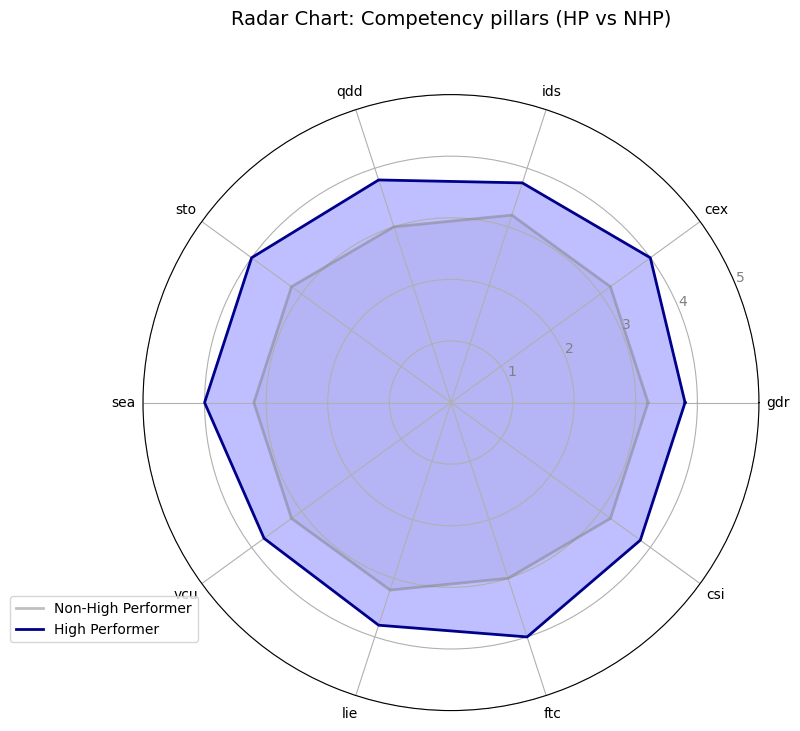

In [11]:
categories = [
    'avg_score_gdr', 'avg_score_cex', 'avg_score_ids', 'avg_score_qdd',
    'avg_score_sto', 'avg_score_sea', 'avg_score_vcu', 'avg_score_lie',
    'avg_score_ftc', 'avg_score_csi'
]

df_plot = df.groupby('high_performer')[categories].median().reset_index()
hp_values = df_plot[df_plot['high_performer'] == True][categories].values[0]
nhp_values = df_plot[df_plot['high_performer'] == False][categories].values[0]
hp_values = np.concatenate((hp_values,[hp_values[0]]))
nhp_values = np.concatenate((nhp_values,[nhp_values[0]]))

N = len(categories)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
ax.plot(angles, nhp_values, linewidth=2, linestyle='solid', label='Non-High Performer', color='gray', alpha=0.5)
ax.fill(angles, nhp_values, 'gray', alpha=0.1)
ax.plot(angles, hp_values, linewidth=2, linestyle='solid', label='High Performer', color='darkblue')
ax.fill(angles, hp_values, 'blue', alpha=0.25)
ax.set_xticks(angles[:-1])
ax.set_xticklabels([c.replace('avg_score_', '') for c in categories])
ax.set_yticks([1, 2, 3, 4, 5])
ax.set_yticklabels(["1", "2", "3", "4", "5"], color="grey", size=10)
ax.set_ylim(0, 5)
plt.title('Radar Chart: Competency pillars (HP vs NHP)', size=14, y=1.1)
ax.legend(loc='lower right', bbox_to_anchor=(0.1, 0.1))
ax.grid(True)
plt.savefig('Radar Chart: Competency pillars (HP vs NHP).png')
plt.show()

In [12]:
categories = [
    'avg_score_gdr', 'avg_score_cex', 'avg_score_ids', 'avg_score_qdd',
    'avg_score_sto', 'avg_score_sea', 'avg_score_vcu', 'avg_score_lie',
    'avg_score_ftc', 'avg_score_csi'
]

df_plot = df.groupby('high_performer')[categories].median().reset_index()

df_competency_comparison = df_plot.set_index('high_performer')[categories].T
df_competency_comparison['Difference'] = df_competency_comparison[True] - df_competency_comparison[False]
df_competency_comparison['Difference (%)'] = (
    (df_competency_comparison['Difference'] / df_competency_comparison[False]) * 100
).round(2)

df_competency_comparison = df_competency_comparison.sort_values(by='Difference (%)', ascending=False)

print("\n--- Percentage Difference in Median Competency Pillars (HP vs NHP) ---")
print(df_competency_comparison[['Difference', 'Difference (%)']])


--- Percentage Difference in Median Competency Pillars (HP vs NHP) ---
high_performer  Difference  Difference (%)
avg_score_ftc         1.00           33.33
avg_score_qdd         0.80           26.67
avg_score_sea         0.80           25.00
avg_score_cex         0.80           25.00
avg_score_sto         0.80           25.00
avg_score_gdr         0.60           18.75
avg_score_csi         0.60           18.75
avg_score_lie         0.60           18.75
avg_score_ids         0.55           17.19
avg_score_vcu         0.55           17.19


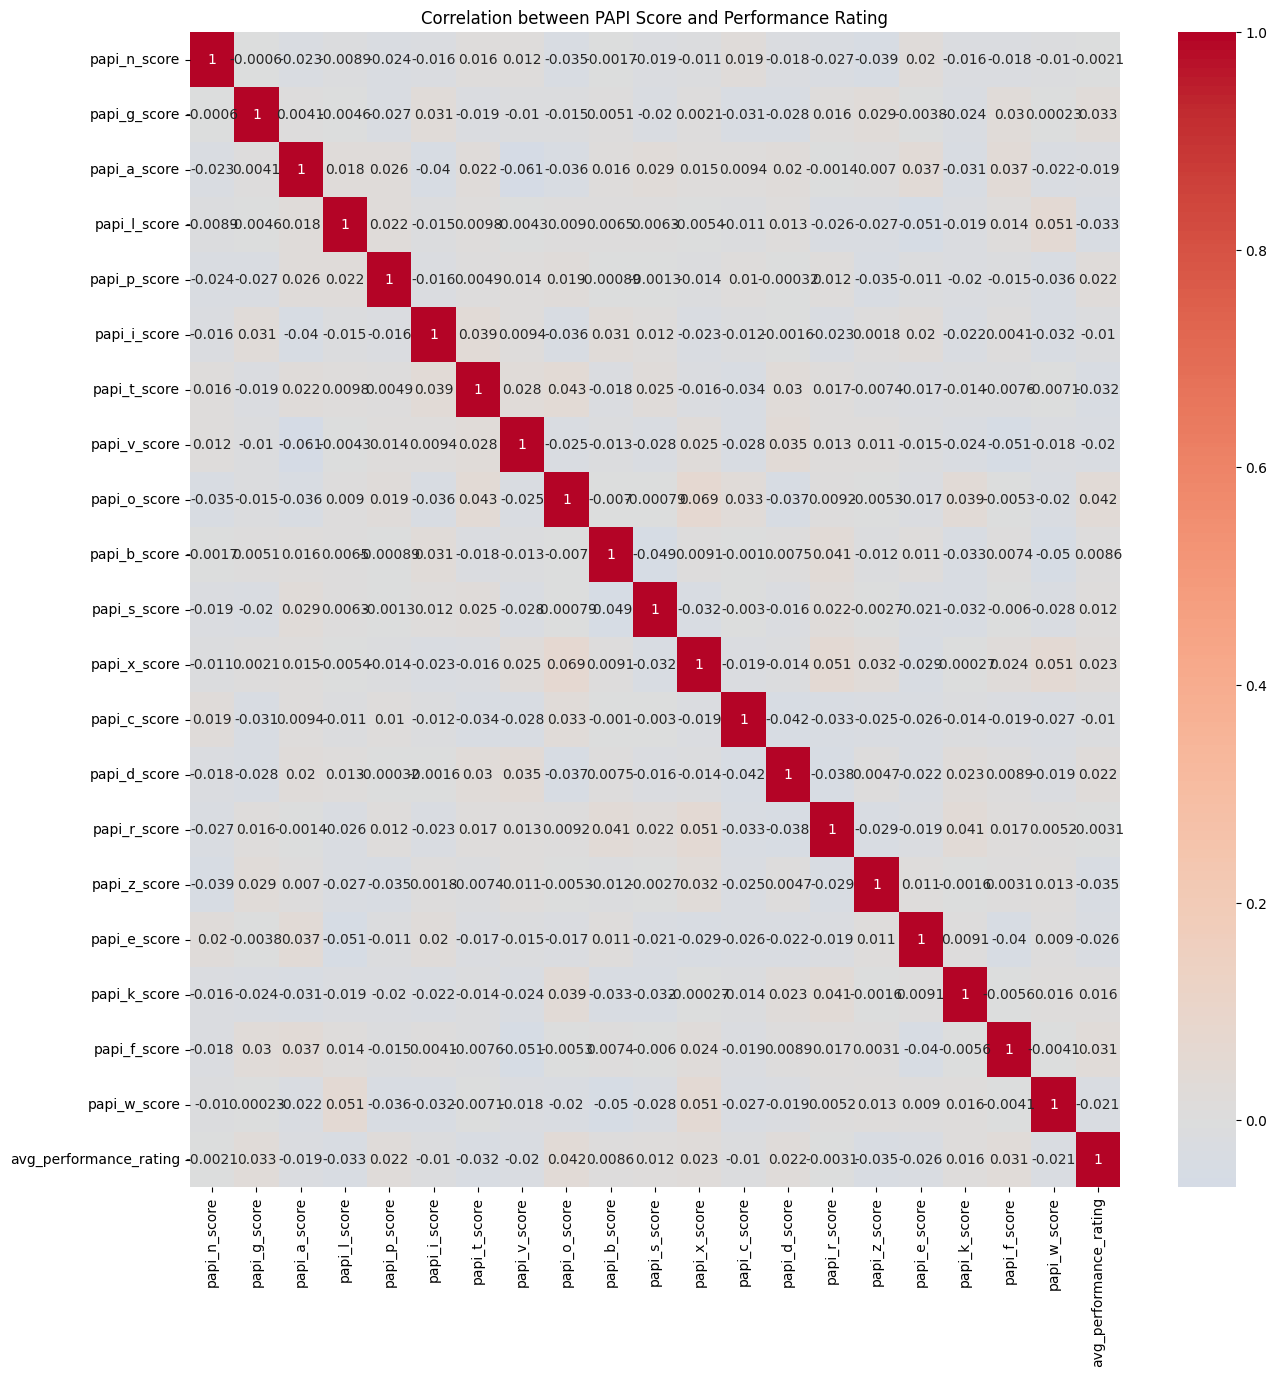

In [13]:
categories = ['papi_n_score', 'papi_g_score', 'papi_a_score', 'papi_l_score',
                  'papi_p_score', 'papi_i_score', 'papi_t_score', 'papi_v_score',
                  'papi_o_score', 'papi_b_score', 'papi_s_score', 'papi_x_score',
                  'papi_c_score', 'papi_d_score', 'papi_r_score', 'papi_z_score',
                  'papi_e_score', 'papi_k_score', 'papi_f_score', 'papi_w_score',
              'avg_performance_rating'
]
corr = df[categories].corr()

plt.figure(figsize=(15,15))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation between PAPI Score and Performance Rating')
plt.savefig('Correlation between PAPI Score and Performance Rating.png')
plt.show()


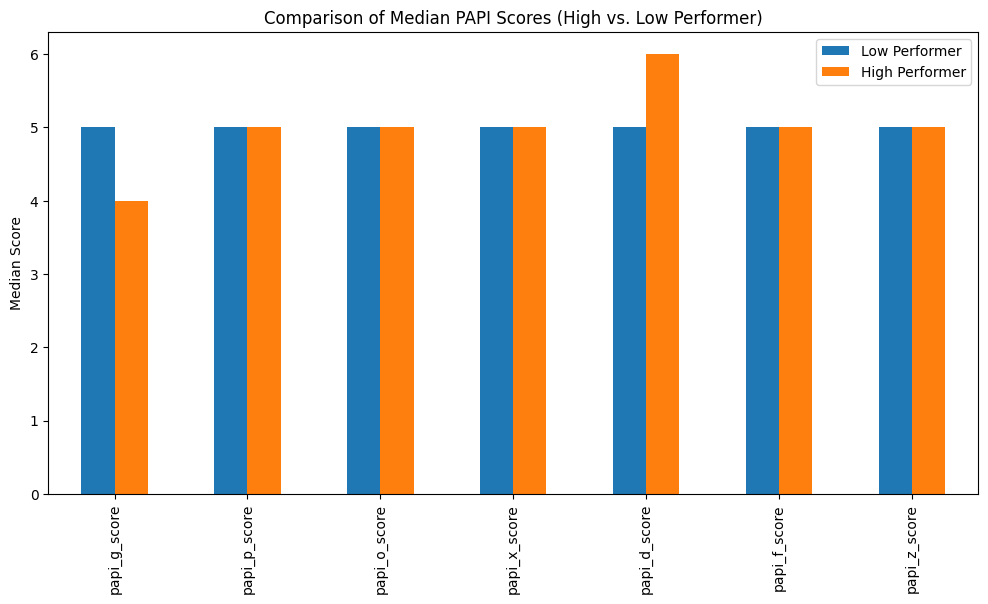

In [15]:
categories = ['papi_g_score', 'papi_p_score', 'papi_o_score', 'papi_x_score',
                  'papi_d_score', 'papi_f_score', 'papi_z_score'
]

numerical_papi = df.groupby('high_performer')[categories].median().T
numerical_papi = numerical_papi.rename(columns={
    True: 'High Performer',
    False: 'Low Performer'
})

numerical_papi.plot(kind='bar', figsize=(12,6))
plt.title('Comparison of Median PAPI Scores (High vs. Low Performer)')
plt.ylabel('Median Score')
plt.xticks(rotation=90)
plt.legend(title=None)
plt.savefig('Comparison of Median PAPI Scores (High vs. Low Performer).png')
plt.show()


In [16]:
numerical_papi['Difference'] = numerical_papi['High Performer'] - numerical_papi['Low Performer']
numerical_papi['Difference (%)'] = ((numerical_papi['Difference']/numerical_papi['Low Performer'])*100)
numerical_papi = numerical_papi.sort_values(by = 'Difference (%)', ascending = False)
print("Different HP and NHP PAPI Score:")
print(numerical_papi[['Difference', 'Difference (%)']].head(10))

Different HP and NHP PAPI Score:
high_performer  Difference  Difference (%)
papi_d_score           1.0            20.0
papi_o_score           0.0             0.0
papi_p_score           0.0             0.0
papi_f_score           0.0             0.0
papi_x_score           0.0             0.0
papi_z_score           0.0             0.0
papi_g_score          -1.0           -20.0


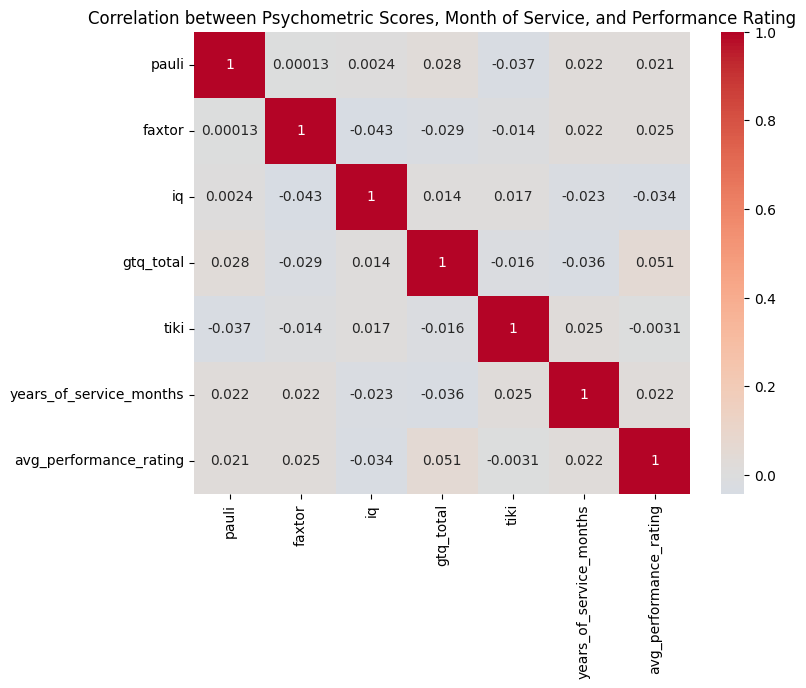

In [17]:
num_cols = ['pauli', 'faxtor', 'iq', 'gtq_total', 'tiki',
            'years_of_service_months', 'avg_performance_rating']

corr = df[num_cols].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation between Psychometric Scores, Month of Service, and Performance Rating')
plt.savefig('Correlation between Psychometric Scores, Month of Service, and Performance Rating.png')
plt.show()


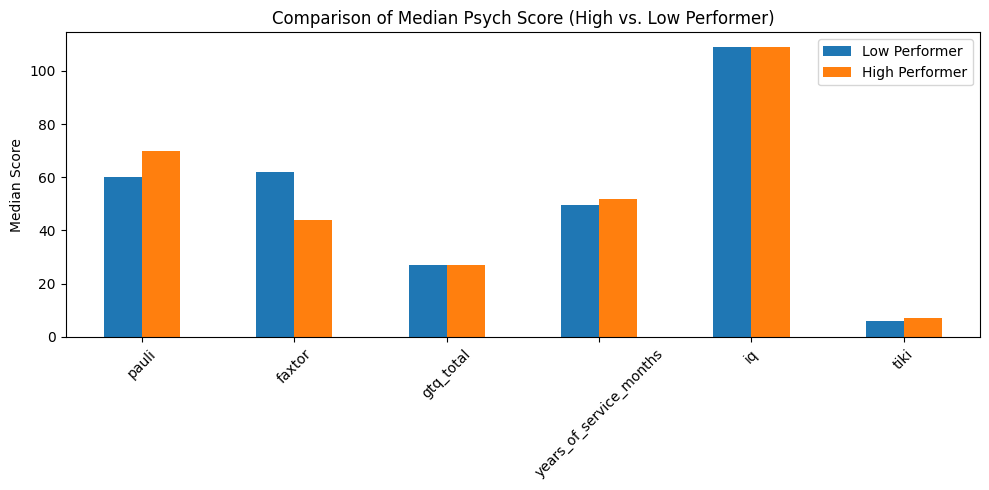

In [46]:
categorical = ['pauli', 'faxtor', 'gtq_total', 'years_of_service_months', 'iq', 'tiki']

numerical_profile_psych = df.groupby('high_performer')[categorical].median().T
numerical_profile_psych = numerical_profile_psych.rename(columns={
    True:'High Performer',
    False:'Low Performer'
})

numerical_profile_psych.plot(kind='bar', figsize=(10,5))
plt.title('Comparison of Median Psych Score (High vs. Low Performer)')
plt.ylabel('Median Score')
plt.xticks(rotation=45)
plt.legend(title=None)
plt.tight_layout()
plt.savefig('Comparison of Median Psych Score (High vs. Low Performer).png')
plt.show()


In [47]:
numerical_profile_psych['Difference'] = numerical_profile_psych['High Performer'] - numerical_profile_psych['Low Performer']
numerical_profile_psych['Difference (%)'] = ((numerical_profile_psych['Difference']/numerical_profile_psych['Low Performer'])*100)
numerical_profile_psych = numerical_profile_psych.sort_values(by = 'Difference (%)', ascending = False)
print("Difference HP and NHP Psych Score:")
print(numerical_profile_psych[['Difference', 'Difference (%)']].head(10))

Difference HP and NHP Psych Score:
high_performer           Difference  Difference (%)
pauli                          10.0       16.666667
tiki                            1.0       16.666667
years_of_service_months         2.5        5.050505
gtq_total                       0.0        0.000000
iq                              0.0        0.000000
faxtor                        -18.0      -29.032258


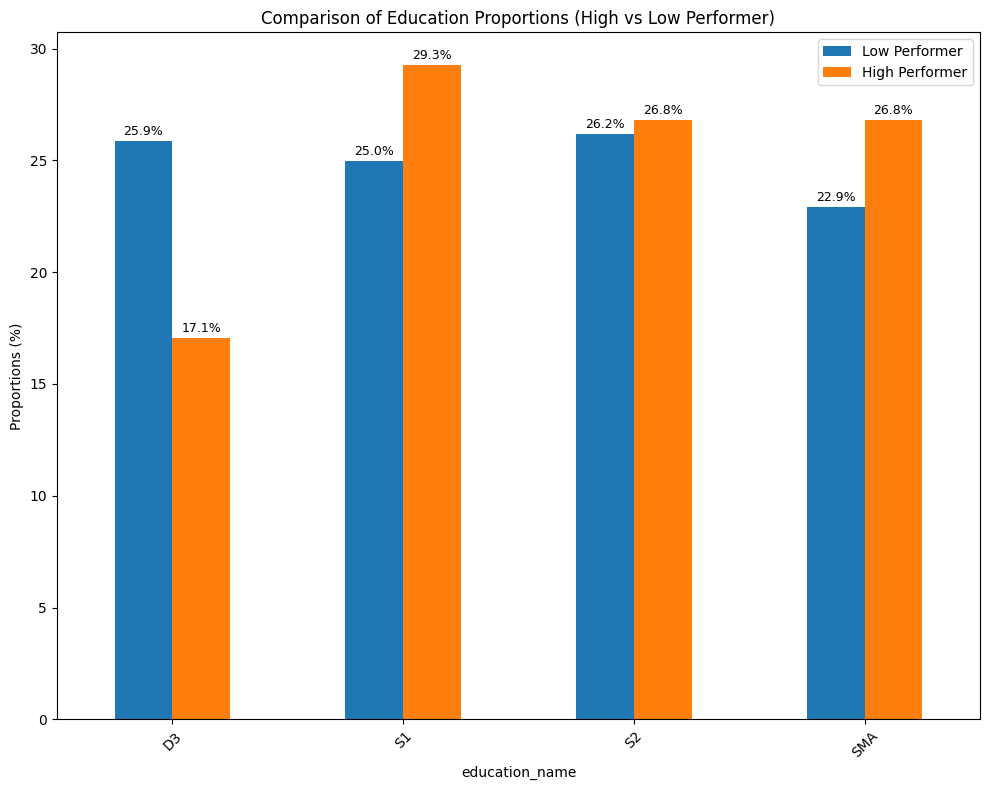

In [36]:
from matplotlib.patches import Patch
categorical = 'education_name'

category_education_name = (
      df.groupby(['high_performer', categorical])
      .size()
      .groupby(level=0)
      .apply(lambda x: (x / x.sum()) * 100)
      .unstack()
)

category_education_name = category_education_name.rename(index={
    True: 'High Performer',
    False: 'Low Performer'
})

ax = category_education_name.T.plot(kind='bar',
                                    figsize=(10,8),
                                    color=['#1f77b4', '#ff7f0e']
                                    )

plt.title('Comparison of Education Proportions (High vs Low Performer)')
plt.ylabel('Proportions (%)')
plt.xticks(rotation=45)
plt.tight_layout()

for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%.1f%%',
        label_type='edge',
        fontsize=9,
        padding=2
)

legend_elements = [
    Patch(facecolor='#1f77b4', label='Low Performer'),
    Patch(facecolor='#ff7f0e', label='High Performer')
]
plt.legend(handles=legend_elements, title=None)
plt.savefig('Comparison of Education Proportions (High vs Low Performer).png')
plt.show()


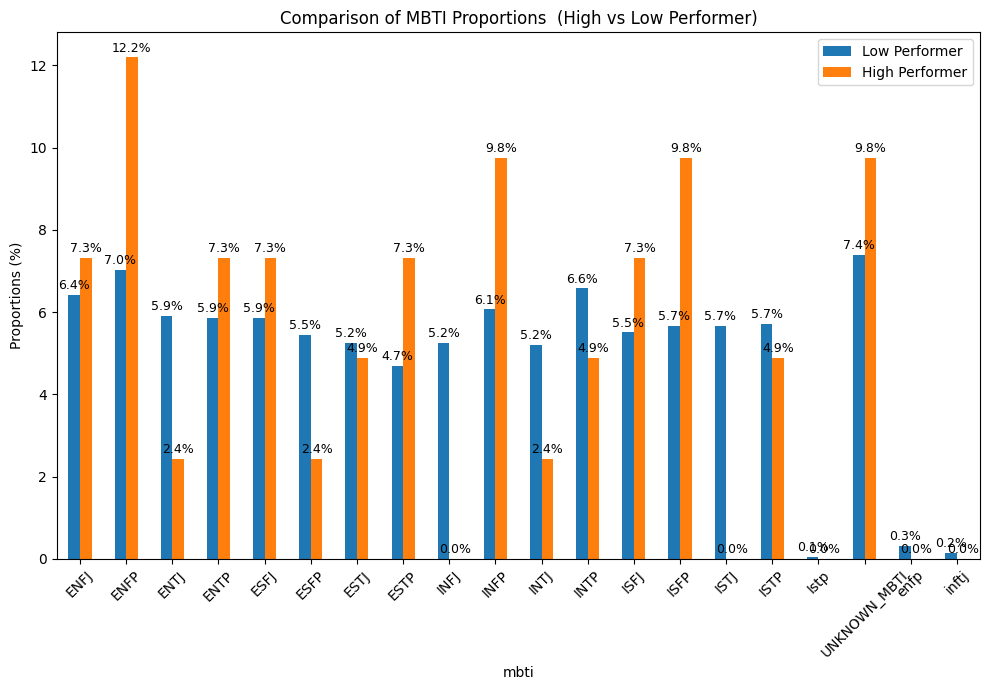

In [37]:
categorical = 'mbti'

category_mbti = (
    df.groupby(['high_performer', categorical])
      .size()
      .groupby(level=0)
      .apply(lambda x: (x / x.sum()) * 100)
      .unstack()
)

category_mbti = category_mbti.rename(index={
    True: 'High Performer',
    False: 'Low Performer'
})

ax = category_mbti.T.plot(
    kind='bar',
    figsize=(10,7),
    color=['#1f77b4', '#ff7f0e']
)

plt.title('Comparison of MBTI Proportions  (High vs Low Performer)')
plt.ylabel('Proportions (%)')
plt.xticks(rotation=45)
plt.tight_layout()

for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%.1f%%',
        label_type='edge',
        fontsize=9,
        padding=2
)

legend_elements = [
    Patch(facecolor='#1f77b4', label='Low Performer'),
    Patch(facecolor='#ff7f0e', label='High Performer')
]
plt.legend(handles=legend_elements, title=None)
plt.savefig('Comparison of MBTI Proportions  (High vs Low Performer).png')
plt.show()


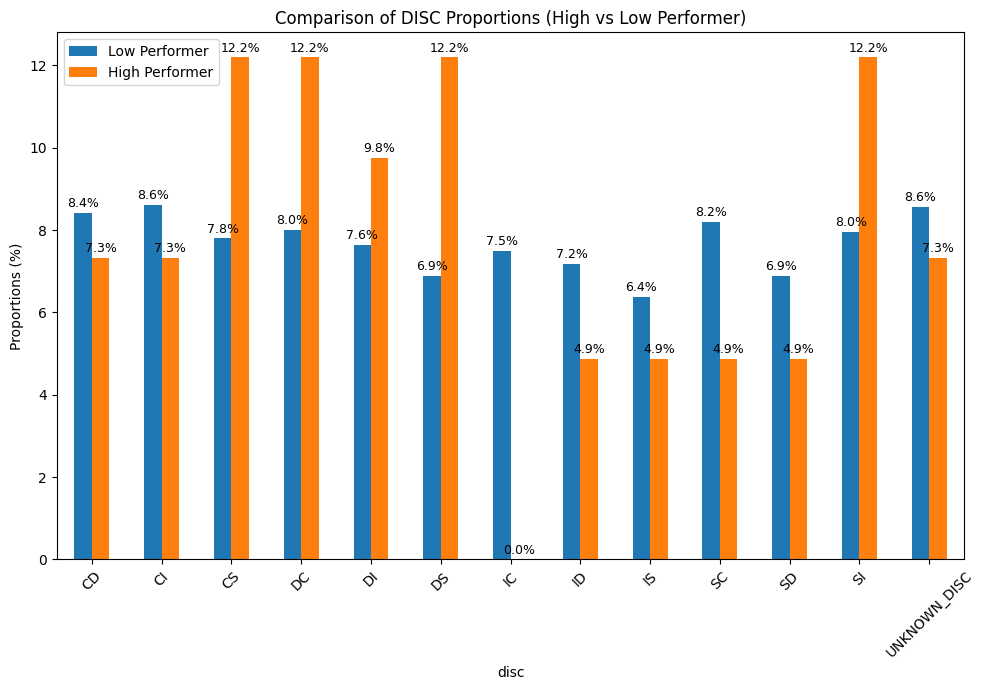

In [38]:
categorical = 'disc'

category_disc = (
    df.groupby(['high_performer', categorical])
      .size()
      .groupby(level=0)
      .apply(lambda x: (x / x.sum()) * 100)
      .unstack()
)

category_disc = category_disc.rename(index={
    True: 'High Performer',
    False: 'Low Performer'
})

ax = category_disc.T.plot(
    kind='bar',
    figsize=(10,7),
    color=['#1f77b4', '#ff7f0e'])

plt.title('Comparison of DISC Proportions (High vs Low Performer)')
plt.ylabel('Proportions (%)')
plt.xticks(rotation=45)
plt.tight_layout()

for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%.1f%%',
        label_type='edge',
        fontsize=9,
        padding=2
)

legend_elements = [
    Patch(facecolor='#1f77b4', label='Low Performer'),
    Patch(facecolor='#ff7f0e', label='High Performer')
]
plt.legend(handles=legend_elements, title=None)
plt.savefig('Comparison of DISC Proportions (High vs Low Performer).png')
plt.show()


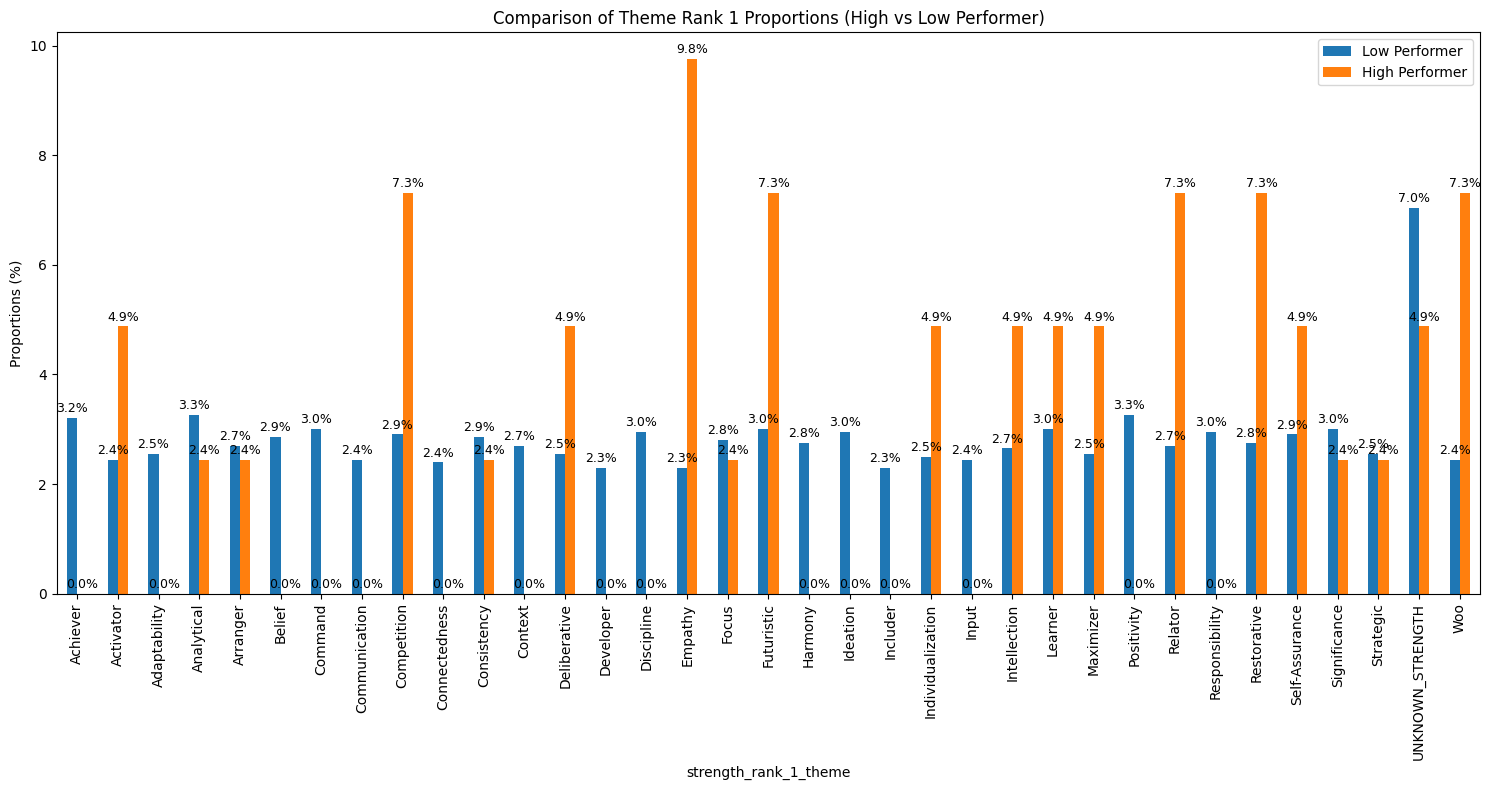

In [39]:
categorical = 'strength_rank_1_theme'

category_rank_1 = (
    df.groupby(['high_performer', categorical])
      .size()
      .groupby(level=0)
      .apply(lambda x: (x / x.sum()) * 100)
      .unstack()
)

category_rank_1 = category_rank_1.rename(index={
    True: 'High Performer',
    False: 'Low Performer'
})

ax = category_rank_1.T.plot(
    kind='bar',
    figsize=(15,8),
    color=['#1f77b4', '#ff7f0e']
)

plt.title('Comparison of Theme Rank 1 Proportions (High vs Low Performer)')
plt.ylabel('Proportions (%)')
plt.xticks(rotation=90)
plt.tight_layout()

for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%.1f%%',
        label_type='edge',
        fontsize=9,
        padding=2
)

# bikin legend manual
legend_elements = [
    Patch(facecolor='#1f77b4', label='Low Performer'),
    Patch(facecolor='#ff7f0e', label='High Performer')
]
plt.legend(handles=legend_elements, title=None)
plt.savefig('Comparison of Theme Rank 1 Proportions (High vs Low Performer).png')
plt.show()


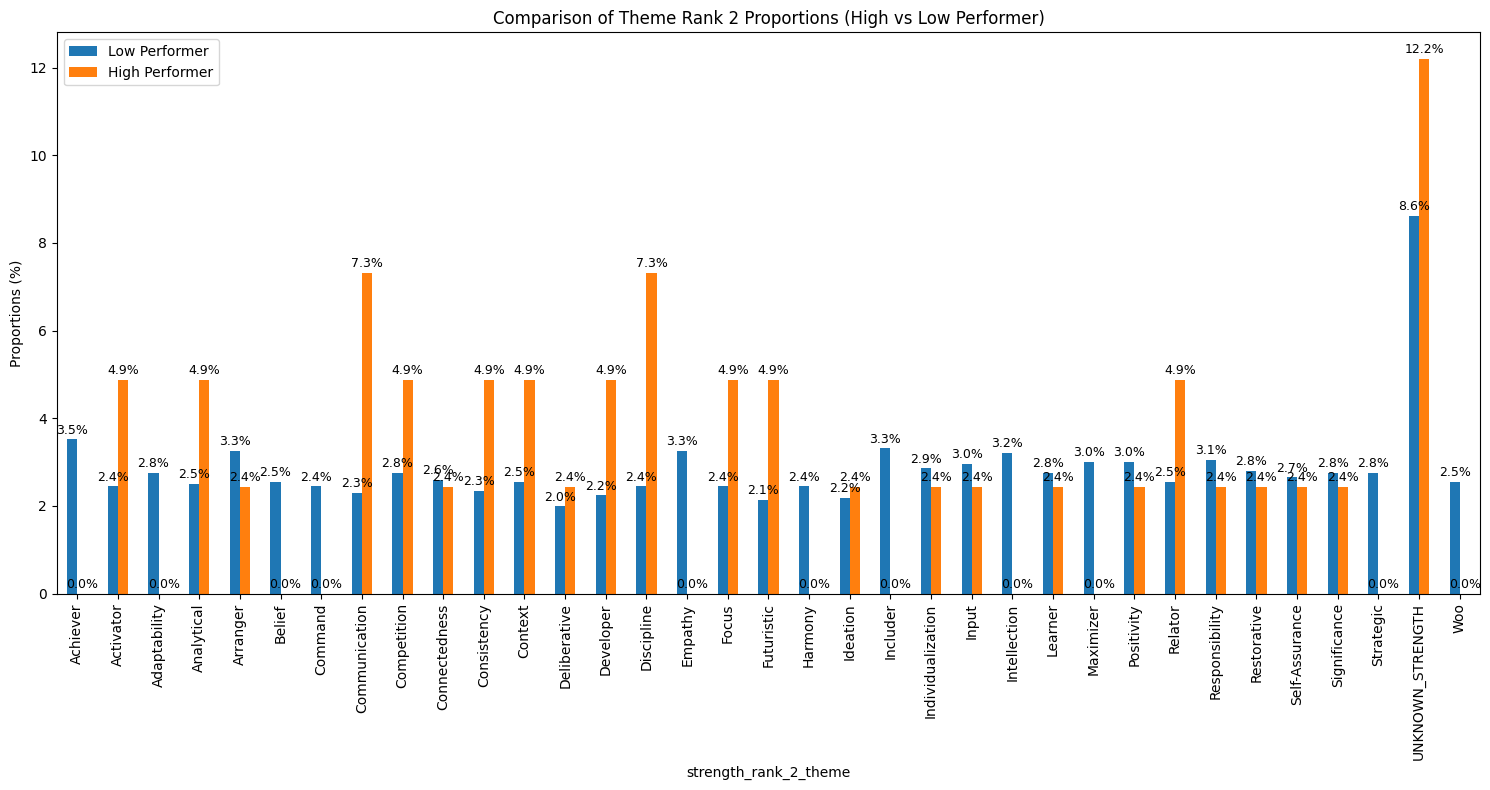

In [40]:
categorical = 'strength_rank_2_theme'

category_rank_2 = (
    df.groupby(['high_performer', categorical])
      .size()
      .groupby(level=0)
      .apply(lambda x: (x / x.sum()) * 100)
      .unstack()
)

category_rank_2 = category_rank_2.rename(index={
    True: 'High Performer',
    False: 'Low Performer'
})

ax = category_rank_2.T.plot(
    kind='bar',
    figsize=(15,8),
    color=['#1f77b4', '#ff7f0e']
)

plt.title('Comparison of Theme Rank 2 Proportions (High vs Low Performer)')
plt.ylabel('Proportions (%)')
plt.xticks(rotation=90)
plt.tight_layout()

for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%.1f%%',
        label_type='edge',
        fontsize=9,
        padding=2
)

legend_elements = [
    Patch(facecolor='#1f77b4', label='Low Performer'),
    Patch(facecolor='#ff7f0e', label='High Performer')
]
plt.legend(handles=legend_elements, title=None)
plt.savefig('Comparison of Theme Rank 2 Proportions (High vs Low Performer).png')
plt.show()
